### Q2: [Label Construction and Dataset Preparation]

Now, we need to do the following:
1. Extract the corresponding 128×128 land-cover patch from the ESA WorldCover raster.
2. Assign a label using the dominant (mode) class.
3. Map ESA class codes to simplified land-use categories.
4. Perform a 60/40 train-test split.
5. Visualize class distribution.

For each image , resolution = 10m/pixel and we have 128 x 128 pixels.
Total area covered in 1 image = 1.28 km x 1.28 km.

In [1]:
%pip install rasterio

Note: you may need to restart the kernel to use updated packages.


In [2]:
import geopandas as gpd
import rasterio
from rasterio.windows import Window
import numpy as np
import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

For each image in data/rgb, we need to extract the 128 x 128 patch cover where we have resolution st. each pixel is 10m , so we cover 1.28km x 1.28km

In [3]:
raster = rasterio.open("../data/worldcover_bbox_delhi_ncr_2021.tif")

print("CRS:", raster.crs)
print("Resolution:", raster.res)
print("Width, Height:", raster.width, raster.height)

CRS: EPSG:4326
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)
Width, Height: 9602 9600


In [4]:
image_folder = "../data/rgb"

filenames = [f for f in os.listdir(image_folder) if f.endswith(".png")]

coords = []

for fname in filenames:
    lat, lon = fname.replace(".png", "").split("_")
    coords.append((fname, float(lat), float(lon)))

df = pd.DataFrame(coords, columns=["filename", "lat", "lon"])
df.head()

,filename,lat,lon
0,28.2056_76.8558.png,28.2056,76.8558
1,28.2056_76.8646.png,28.2056,76.8646
2,28.2056_76.8734.png,28.2056,76.8734
3,28.2056_76.8822.png,28.2056,76.8822
4,28.2056_76.8910.png,28.2056,76.8910


In [5]:
labels = []

for _, row_data in df.iterrows():
    fname, lat, lon = row_data
    
    # Convert to raster pixel index
    row, col = raster.index(lon, lat)
    
    half = 64
    window = Window(col - half, row - half, 128, 128)
    
    patch = raster.read(1, window=window)
    
    # Flatten and remove zeros (optional if nodata)
    patch_values = patch.flatten()
    
    # Compute dominant class
    most_common = Counter(patch_values).most_common(1)[0][0]
    
    labels.append(most_common)

df["esa_class"] = labels
df.head()

,filename,lat,lon,esa_class
0,28.2056_76.8558.png,28.2056,76.8558,50
1,28.2056_76.8646.png,28.2056,76.8646,50
2,28.2056_76.8734.png,28.2056,76.8734,50
3,28.2056_76.8822.png,28.2056,76.8822,50
4,28.2056_76.8910.png,28.2056,76.8910,40


In [6]:
# ESA worldcover classes
esa_mapping = {
    10: "Vegetation",
    20: "Vegetation",
    30: "Vegetation",
    40: "Cropland",
    50: "Built-up",
    60: "Bare",
    70: "Snow",
    80: "Water",
    90: "Wetland",
    100: "Moss"
}

df["label"] = df["esa_class"].map(lambda x: esa_mapping.get(x, "Others"))
df.head()

,filename,lat,lon,esa_class,label
0,28.2056_76.8558.png,28.2056,76.8558,50,Built-up
1,28.2056_76.8646.png,28.2056,76.8646,50,Built-up
2,28.2056_76.8734.png,28.2056,76.8734,50,Built-up
3,28.2056_76.8822.png,28.2056,76.8822,50,Built-up
4,28.2056_76.8910.png,28.2056,76.8910,40,Cropland


In [7]:
train_df, test_df = train_test_split(df, test_size=0.4, random_state=42, stratify=df["label"])

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 5529
Test size: 3687


In [8]:
# Run this at the end of your q2_labels.ipynb
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

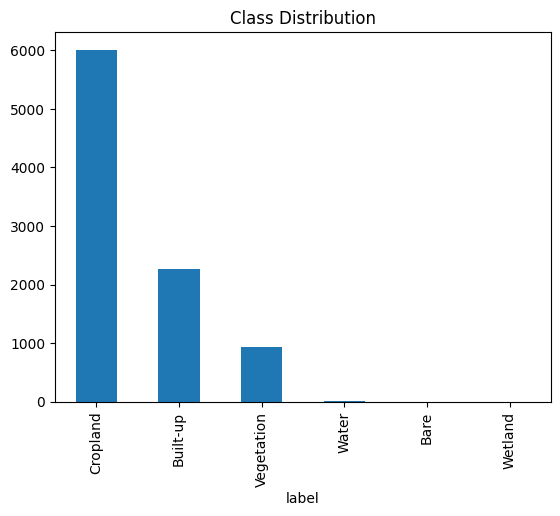

In [9]:
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()